<a href="https://colab.research.google.com/github/Jayatheerthan24/motor_claims/blob/main/4_motor_claims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("claims.csv")

print("First 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()

print("\nDataset After Cleaning:")
print(df.shape)


First 5 Records:
  claim_id  policy_value_inr  claim_amount_inr  incident_description_length  \
0   CL0001            903872             29185                         73.0   
1   CL0002           1161864            211461                        358.0   
2   CL0003            659252             84010                        336.0   
3   CL0004            957689             46181                         60.0   
4   CL0005           1178840             66976                         76.0   

   previous_claim_count claim_outcome  
0                   1.0        Normal  
1                   2.0        Normal  
2                   3.0       Flagged  
3                   2.0        Normal  
4                   1.0        Normal  

Dataset Shape:
(123, 6)

Column Names:
Index(['claim_id', 'policy_value_inr', 'claim_amount_inr',
       'incident_description_length', 'previous_claim_count', 'claim_outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIn

In [19]:
print("\nDescriptive Statistics:")
print(df.describe())

df["claim_ratio"] = df["claim_amount_inr"] / df["policy_value_inr"]

print("\nClaim Ratio:")
print(df[["claim_amount_inr", "policy_value_inr", "claim_ratio"]].head())

Q1 = df["claim_amount_inr"].quantile(0.25)
Q3 = df["claim_amount_inr"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["claim_amount_inr"] < lower_limit) |
    (df["claim_amount_inr"] > upper_limit)
]

print("\nNumber of Unusual Claims:")
print(len(outliers))


Descriptive Statistics:
       policy_value_inr  claim_amount_inr  incident_description_length  \
count      1.170000e+02        117.000000                   117.000000   
mean       7.296969e+05     101017.042735                   263.623932   
std        3.100184e+05      68806.242517                   138.963201   
min        1.688760e+05      24900.000000                    30.000000   
25%        4.934330e+05      55405.000000                   153.000000   
50%        6.993460e+05      83741.000000                   258.000000   
75%        1.029842e+06     125703.000000                   365.000000   
max        1.198734e+06     480311.000000                   492.000000   

       previous_claim_count  claim_ratio  
count            117.000000   117.000000  
mean               1.205128     0.180980  
std                1.133643     0.175154  
min                0.000000     0.022917  
25%                0.000000     0.079714  
50%                1.000000     0.125494  
75%    

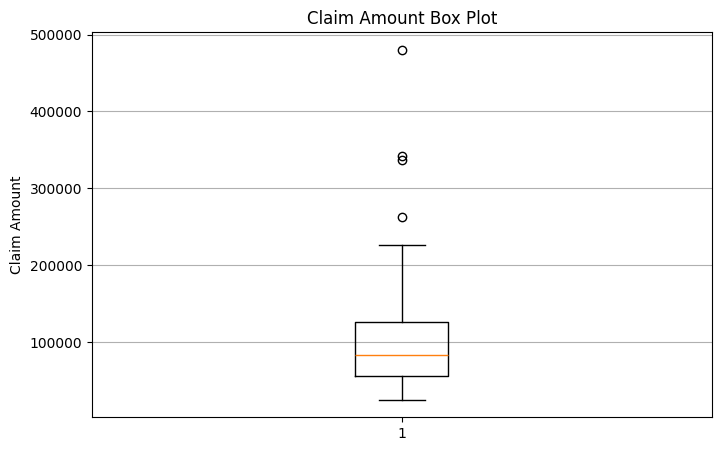

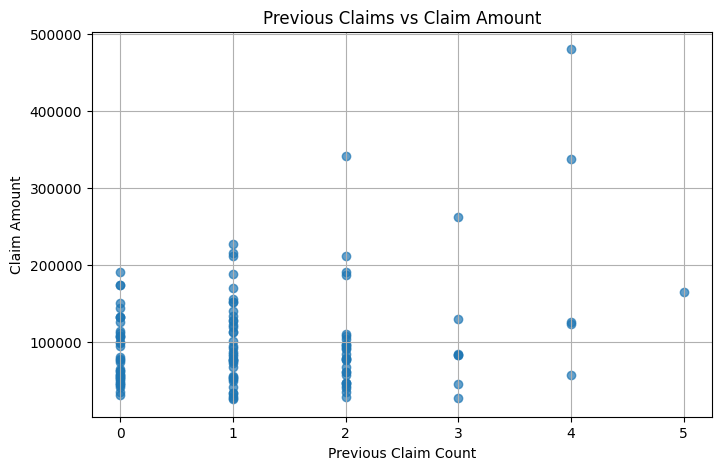

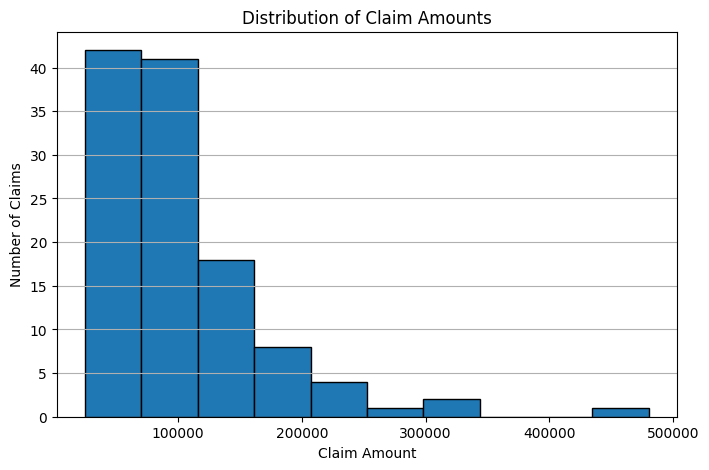

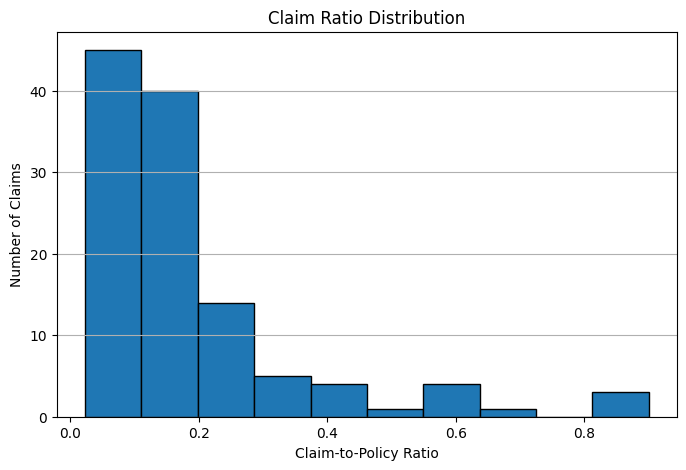


Unusual / Potentially Suspicious Claims:
    claim_amount_inr  policy_value_inr  claim_ratio  previous_claim_count
27            341576            531109     0.643137                   2.0
47            336829            569453     0.591496                   4.0
53            480311            777750     0.617565                   4.0
86            262510           1106255     0.237296                   3.0


In [26]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["claim_amount_inr"])
plt.title("Claim Amount Box Plot")
plt.ylabel("Claim Amount")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    df["previous_claim_count"],
    df["claim_amount_inr"],
    alpha=0.7
)
plt.xlabel("Previous Claim Count")
plt.ylabel("Claim Amount")
plt.title("Previous Claims vs Claim Amount")
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(
    df["claim_amount_inr"],
    bins=10,
    edgecolor="black"
)
plt.xlabel("Claim Amount")
plt.ylabel("Number of Claims")
plt.title("Distribution of Claim Amounts")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(
    df["claim_ratio"],
    bins=10,
    edgecolor="black"
)
plt.xlabel("Claim-to-Policy Ratio")
plt.ylabel("Number of Claims")
plt.title("Claim Ratio Distribution")
plt.grid(axis="y")
plt.show()

print("\nUnusual / Potentially Suspicious Claims:")
print(
    outliers[
        [
            "claim_amount_inr",
            "policy_value_inr",
            "claim_ratio",
            "previous_claim_count"
        ]
    ]
)


In [28]:
print("Total Claims:", len(df))

print(
    "Average Claim Amount:",
    round(df["claim_amount_inr"].mean(), 2)
)

print(
    "Maximum Claim Amount:",
    round(df["claim_amount_inr"].max(), 2)
)

print(
    "Minimum Claim Amount:",
    round(df["claim_amount_inr"].min(), 2)
)

print(
    "Average Claim Ratio:",
    round(df["claim_ratio"].mean(), 2)
)

print("Potential Unusual Claims:", len(outliers))

Total Claims: 117
Average Claim Amount: 101017.04
Maximum Claim Amount: 480311
Minimum Claim Amount: 24900
Average Claim Ratio: 0.18
Potential Unusual Claims: 4
